# Install (if needed) and Import Libraries

In [183]:
# Installation of pysentiment2 to get access to Loughran-McDonald Dictionary
# !pip install pysentiment2
# !pip install matplotlib
# !pip install openpyxl    


import numpy as np
import pandas as pd
import pysentiment2 as ps

import nltk as nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re

# Load the xlsx file and check the DataFrame

In [184]:
filename = "../datasets/final/mda_shared_preprocessed.csv"
data = pd.read_csv(filename)
# data = pd.read_excel(filename) # Use the sheet with stopwords removed

data.head()

# INFO:
# each sentence belongs to 1 document, sentiment is golden label

# Relabel sentiment column for easier reference
data.rename(columns={"sentiment": "golden_sentiment_label"}, inplace=True)

data.head()



,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately NUM of all sales were generated ...,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral


# Remove blank sentences as we don't need to do any analysis

In [185]:
golden_df = data.copy()

golden_df.head()


# Quick check to see if there is any NaNs in the df
golden_df.isna().sum() # If 0 means there is no NaNs

golden_df.info() # 452390 entries


# NO NEED TO DO THIS WITH FINAL FILE - IGNORE
# # Split sentences into individual rows
# golden_df = data.copy()
# golden_df = data.melt(id_vars=["doc"], var_name="sentence_id", value_name="sentence")

# golden_df.head() # temp check its done correctly


# SIMPLE PROCESSING
# Drop NaNs for rows with empty sentences - Just in case there is any missed
golden_df = golden_df.dropna(subset=["sentence"])
# In case there are sentences that are empty but not marked NaN
golden_df = golden_df[golden_df["sentence"].astype(str).str.strip() != ""]
# Make all sentences ALL lowercase
golden_df["sentence"] = golden_df["sentence"].str.lower()


# Check
golden_df.info()
golden_df.head()


# # Ensure that the melted DF is still the same as the original DF
# sentence_cols = [col for col in data.columns if col.startswith("sent_")]
# mask = data[sentence_cols].apply(lambda col: col.map(lambda x: pd.notna(x) and str(x).strip() != ""))
# original_nonempty_count = mask.sum().sum()
# long_count = golden_df.shape[0]

# print("Original real sentence cells:", original_nonempty_count)
# print("Rows in melted df:", long_count)
# print("Match?", original_nonempty_count == long_count)



<class 'pandas.DataFrame'>
RangeIndex: 452390 entries, 0 to 452389
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   doc_id                  452390 non-null  str  
 1   company_name            452390 non-null  str  
 2   filing_type             452390 non-null  str  
 3   filing_date             452390 non-null  str  
 4   year                    452390 non-null  int64
 5   quarter                 452390 non-null  str  
 6   sentence                452390 non-null  str  
 7   golden_sentiment_label  452390 non-null  str  
dtypes: int64(1), str(7)
memory usage: 27.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 452390 entries, 0 to 452389
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   doc_id                  452390 non-null  str  
 1   company_name            452390 non-null  str  
 2   filing_type           

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately num of all sales were generated ...,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral


# Loughran-McDonald

## 1a. Prepare scoring for each sentence (using LM)

NOTE: pysentiment2 is outdated as it still uses the 2018 dictionary! We will implement our own with the updated 2024 dictionary

In [186]:
# Initialise
lm = ps.LM()

# For a sentence, score using LM and return Positive, Negative, Polarity, Subjectivity
def analyse_lm(text):
    tokens = lm.tokenize(str(text))
    score = lm.get_score(tokens)
    return pd.Series({ # Return so we can append to each row in df
        "positive": score["Positive"],
        "negative": score["Negative"],
        "polarity": score["Polarity"],
        "subjectivity": score["Subjectivity"]
    })

def analyse_lm_test(text):
    tokens = lm.tokenize(str(text))
    return lm.get_score(tokens)



# NOTE:
# Positive number is the word counts for words in positive set
# Negative number is the word counts for words in negative set
# Polarity calculated with P-N/P+N (Overall Sentiment)
# Subjectivity = P+N/Total Tokens (How many of the tokens were sentiment-bearing words)

## 1b. Start scoring each sentence (using **UPDATED** LM2024)


In [187]:
lm_dict = pd.read_csv("../datasets/final/Loughran-McDonald_MasterDictionary_1993-2024.csv")
print(lm_dict[["Word", "Positive", "Negative"]].tail())


# We make all words to lower to try and match the sentences

positive_words = set(
    lm_dict.loc[lm_dict["Positive"] > 0, "Word"]
    .str.lower()
    .str.strip()
)

negative_words = set(
    lm_dict.loc[lm_dict["Negative"] > 0, "Word"]
    .str.lower()
    .str.strip()
)

print("Positive words:", len(positive_words))
print("Negative words:", len(negative_words))

            Word  Positive  Negative
86548     ZYGOTE         0         0
86549    ZYGOTES         0         0
86550    ZYGOTIC         0         0
86551  ZYMURGIES         0         0
86552    ZYMURGY         0         0
Positive words: 347
Negative words: 2345


In [188]:
# Sanity check...
if "able" in positive_words:
    print("ok")

if "absenteeism" in negative_words:
    print("ok2")

ok
ok2


In [189]:
# Creating functions for custom LM analyser

def tokenize_lm_text(text):
    # This will remove punctuation and drop placeholders like NUM
    text = str(text).lower() # Don't trust myself, lowercase everything again
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if token != "num"]
    return tokens


def analyse_lm_CUSTOM(text):
    tokens = tokenize_lm_text(text)
    
    if len(tokens) == 0:
        return pd.Series({
            "positive": 0.0,
            "negative": 0.0,
            "polarity": 0.0,
            "subjectivity": 0.0
        })
    
    pos_count = sum(token in positive_words for token in tokens)
    neg_count = sum(token in negative_words for token in tokens)
    token_count = len(tokens)
    
    positive = pos_count / token_count
    negative = neg_count / token_count
    
    if (pos_count + neg_count) == 0:
        polarity = 0.0
        subjectivity = 0.0
    else:
        polarity = (pos_count - neg_count) / (pos_count + neg_count)
        subjectivity = (pos_count + neg_count) / token_count
    
    return pd.Series({
        "positive": positive,
        "negative": negative,
        "polarity": polarity,
        "subjectivity": subjectivity,
        "pos_count": pos_count,
        "neg_count": neg_count
    })


def analyse_lm_CUSTOMTEST(text):
    tokens = tokenize_lm_text(text)
    
    if len(tokens) == 0:
        return pd.Series({
            "positive": 0.0,
            "negative": 0.0,
            "polarity": 0.0,
            "subjectivity": 0.0
        })
    
    pos_count = sum(token in positive_words for token in tokens)
    neg_count = sum(token in negative_words for token in tokens)
    token_count = len(tokens)
    
    positive = pos_count / token_count
    negative = neg_count / token_count
    
    if (pos_count + neg_count) == 0:
        polarity = 0.0
        subjectivity = 0.0
    else:
        polarity = (pos_count - neg_count) / (pos_count + neg_count)
        subjectivity = (pos_count + neg_count) / token_count
    
    return {
        "Positive": positive,
        "Negative": negative,
        "Polarity": polarity,
        "Subjectivity": subjectivity
    }

### Actually do the scoring HERE **PLEASE PAY ATTENTION HERE PLEASE**

In [190]:
# Make a copy
df_pysentiment = golden_df.copy()
df_custom = golden_df.copy()

# Feed each sentence to function, get the result
scores_pysentiment = df_pysentiment["sentence"].apply(analyse_lm) # USING pysentiment2
scores_custom = df_custom["sentence"].apply(analyse_lm_CUSTOM) # USING CUSTOM


# Combine scores to each row, have 2 dataframes in play right now
df_pysentiment = pd.concat([df_pysentiment, scores_pysentiment], axis=1)
df_custom = pd.concat([df_custom, scores_custom], axis=1)


In [191]:
df_pysentiment.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label,positive,negative,polarity,subjectivity
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral,1.0,0.0,0.999999,0.062500
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately num of all sales were generated ...,neutral,0.0,0.0,0.000000,0.000000
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral,0.0,1.0,-0.999999,0.062500
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral,1.0,0.0,0.999999,0.066667
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral,0.0,0.0,0.000000,0.000000


In [192]:
df_custom.head() # Custom has more columns returned because I realised positive, negative is overall counts / total token count, not the same as df_pysentiment

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label,positive,negative,polarity,subjectivity,pos_count,neg_count
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral,0.045455,0.000000,1.0,0.045455,1.0,0.0
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately num of all sales were generated ...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral,0.000000,0.043478,-1.0,0.043478,0.0,1.0
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0


In [193]:
# Add sentence sentiment label function to compare with the golden_sentiment_label
def label_sentiment(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"
    
# NOTE: sentence is labelled positive or negative based on polarity. This may result in over-labelling sentences as non-neutral, which can affect the results.


In [194]:
# Add the sentiment label determined based on polarity 

df_pysentiment["sentence_sentiment"] = df_pysentiment["polarity"].apply(label_sentiment) # Positive polarity is more positive words than negative
df_custom["sentence_sentiment"] = df_custom["polarity"].apply(label_sentiment)

In [195]:
df_pysentiment.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label,positive,negative,polarity,subjectivity,sentence_sentiment
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral,1.0,0.0,0.999999,0.062500,positive
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately num of all sales were generated ...,neutral,0.0,0.0,0.000000,0.000000,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral,0.0,1.0,-0.999999,0.062500,negative
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral,1.0,0.0,0.999999,0.066667,positive
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral,0.0,0.0,0.000000,0.000000,neutral


In [196]:
df_custom.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label,positive,negative,polarity,subjectivity,pos_count,neg_count,sentence_sentiment
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral,0.045455,0.000000,1.0,0.045455,1.0,0.0,positive
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately num of all sales were generated ...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral,0.000000,0.043478,-1.0,0.043478,0.0,1.0,negative
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0,neutral
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral,0.000000,0.000000,0.0,0.000000,0.0,0.0,neutral


## 2. Aggregate into each document for sentiment analysis

In [197]:
df_custom["token_count"] = df_custom["sentence"].apply(lambda x: len(tokenize_lm_text(x)))

doc_custom = (
    df_custom.groupby(
        ["doc_id", "company_name", "filing_type", "filing_date", "year", "quarter"],
        as_index=False
    )
    .agg(
        n_sentences=("sentence", "count"),
        lm_pos_count=("pos_count", "sum"),
        lm_neg_count=("neg_count", "sum"),
        token_count=("token_count", "sum"),
        document_text=("sentence", " ".join),
        gold_pos_sentences=("golden_sentiment_label", lambda s: (s == "positive").sum()),
        gold_neg_sentences=("golden_sentiment_label", lambda s: (s == "negative").sum()),
        gold_neu_sentences=("golden_sentiment_label", lambda s: (s == "neutral").sum()),
        pred_pos_sentences=("sentence_sentiment", lambda s: (s == "positive").sum()),
        pred_neg_sentences=("sentence_sentiment", lambda s: (s == "negative").sum()),
        pred_neu_sentences=("sentence_sentiment", lambda s: (s == "neutral").sum())
    )
)

In [198]:
doc_custom.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,n_sentences,lm_pos_count,lm_neg_count,token_count,document_text,gold_pos_sentences,gold_neg_sentences,gold_neu_sentences,pred_pos_sentences,pred_neg_sentences,pred_neu_sentences
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,19,4.0,2.0,454,approximately num of all sales were generated ...,2,1,16,2,1,16
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,11,1.0,3.0,247,fiscal num started out with greater than expec...,2,0,9,1,3,7
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,9,1.0,0.0,245,we have continued with working from home where...,0,2,7,1,0,8
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,55,4.0,46.0,1278,management does not believe that the resolutio...,1,0,54,0,25,30
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,8,0.0,6.0,180,num we have direct buying relationships with a...,0,1,7,0,3,5


In [199]:
df_pysentiment["token_count"] = df_pysentiment["sentence"].apply(lambda x: len(lm.tokenize(str(x)))) # Use pysentiment2's own tokenizer
# df_pysentiment["token_count"] = df_pysentiment["sentence"].apply(lambda x: len(tokenize_lm_text(x))) # Use custom tokenzier


doc_pysentiment = (
    df_pysentiment.groupby(
        ["doc_id", "company_name", "filing_type", "filing_date", "year", "quarter"],
        as_index=False
    )
    .agg(
        n_sentences=("sentence", "count"),
        pos_count=("positive", "sum"), # Changed this due to inconsistency in column name earlier
        neg_count=("negative", "sum"), # Changed this due to inconsistency in column name earlier
        token_count=("token_count", "sum"),
        document_text=("sentence", " ".join),
        gold_pos_sentences=("golden_sentiment_label", lambda s: (s == "positive").sum()),
        gold_neg_sentences=("golden_sentiment_label", lambda s: (s == "negative").sum()),
        gold_neu_sentences=("golden_sentiment_label", lambda s: (s == "neutral").sum()),
        pred_pos_sentences=("sentence_sentiment", lambda s: (s == "positive").sum()),
        pred_neg_sentences=("sentence_sentiment", lambda s: (s == "negative").sum()),
        pred_neu_sentences=("sentence_sentiment", lambda s: (s == "neutral").sum())
    )
)

In [200]:
doc_pysentiment.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,n_sentences,pos_count,neg_count,token_count,document_text,gold_pos_sentences,gold_neg_sentences,gold_neu_sentences,pred_pos_sentences,pred_neg_sentences,pred_neu_sentences
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,19,6.0,4.0,270,approximately num of all sales were generated ...,2,1,16,3,1,15
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,11,4.0,3.0,141,fiscal num started out with greater than expec...,2,0,9,2,2,7
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,9,5.0,0.0,146,we have continued with working from home where...,0,2,7,3,0,6
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,55,16.0,57.0,666,management does not believe that the resolutio...,1,0,54,3,28,24
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,8,1.0,7.0,96,num we have direct buying relationships with a...,0,1,7,1,4,3


In [201]:
# Now, add calculate polarity and subjectivity for both df at the document level

doc_pysentiment["polarity"] = 0.0 # Overall direction of sentiment in the whole document, closer to 1 is more positive
doc_pysentiment["subjectivity"] = 0.0 # How much of the document contains sentiment bearing words

mask_pol = (doc_pysentiment["pos_count"] + doc_pysentiment["neg_count"]) > 0
mask_tok = doc_pysentiment["token_count"] > 0

doc_pysentiment.loc[mask_pol, "polarity"] = (
    (doc_pysentiment.loc[mask_pol, "pos_count"] - doc_pysentiment.loc[mask_pol, "neg_count"]) /
    (doc_pysentiment.loc[mask_pol, "pos_count"] + doc_pysentiment.loc[mask_pol, "neg_count"])
)

doc_pysentiment.loc[mask_tok, "subjectivity"] = (
    (doc_pysentiment.loc[mask_tok, "pos_count"] + doc_pysentiment.loc[mask_tok, "neg_count"]) /
    doc_pysentiment.loc[mask_tok, "token_count"]
)


# Doing the same thing but for doc_custom

doc_custom["polarity"] = 0.0 # Overall direction of sentiment in the whole document, closer to 1 is more positive
doc_custom["subjectivity"] = 0.0 # How much of the document contains sentiment bearing words

mask_pol_custom = (doc_custom["lm_pos_count"] + doc_custom["lm_neg_count"]) > 0
mask_tok_custom = doc_custom["token_count"] > 0

doc_custom.loc[mask_pol_custom, "polarity"] = (
    (doc_custom.loc[mask_pol_custom, "lm_pos_count"] - doc_custom.loc[mask_pol_custom, "lm_neg_count"]) /
    (doc_custom.loc[mask_pol_custom, "lm_pos_count"] + doc_custom.loc[mask_pol_custom, "lm_neg_count"])
)

doc_custom.loc[mask_tok_custom, "subjectivity"] = (
    (doc_custom.loc[mask_tok_custom, "lm_pos_count"] + doc_custom.loc[mask_tok_custom, "lm_neg_count"]) /
    doc_custom.loc[mask_tok_custom, "token_count"]
)

In [202]:
doc_pysentiment.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,n_sentences,pos_count,neg_count,token_count,document_text,gold_pos_sentences,gold_neg_sentences,gold_neu_sentences,pred_pos_sentences,pred_neg_sentences,pred_neu_sentences,polarity,subjectivity
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,19,6.0,4.0,270,approximately num of all sales were generated ...,2,1,16,3,1,15,0.200000,0.037037
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,11,4.0,3.0,141,fiscal num started out with greater than expec...,2,0,9,2,2,7,0.142857,0.049645
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,9,5.0,0.0,146,we have continued with working from home where...,0,2,7,3,0,6,1.000000,0.034247
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,55,16.0,57.0,666,management does not believe that the resolutio...,1,0,54,3,28,24,-0.561644,0.109610
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,8,1.0,7.0,96,num we have direct buying relationships with a...,0,1,7,1,4,3,-0.750000,0.083333


In [203]:
doc_custom.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,n_sentences,lm_pos_count,lm_neg_count,token_count,document_text,gold_pos_sentences,gold_neg_sentences,gold_neu_sentences,pred_pos_sentences,pred_neg_sentences,pred_neu_sentences,polarity,subjectivity
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,19,4.0,2.0,454,approximately num of all sales were generated ...,2,1,16,2,1,16,0.333333,0.013216
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,11,1.0,3.0,247,fiscal num started out with greater than expec...,2,0,9,1,3,7,-0.500000,0.016194
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,9,1.0,0.0,245,we have continued with working from home where...,0,2,7,1,0,8,1.000000,0.004082
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,55,4.0,46.0,1278,management does not believe that the resolutio...,1,0,54,0,25,30,-0.840000,0.039124
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,8,0.0,6.0,180,num we have direct buying relationships with a...,0,1,7,0,3,5,-1.000000,0.033333


## 3. Do some cool visualisations (for LM)

In [204]:
# Import libraries
import matplotlib.pyplot as plt

In [205]:
# Create a new trend df that will be used as visualisation

doc_custom["filing_date"] = pd.to_datetime(doc_custom["filing_date"])

polarity_trend_custom = (
    doc_custom.groupby(["company_name", "filing_type", "filing_date"], as_index=False)
    .agg(
        avg_polarity=("polarity", "mean"),
        n_docs=("doc_id", "count")
    )
    .sort_values(["company_name", "filing_type", "filing_date"])
)

doc_pysentiment["filing_date"] = pd.to_datetime(doc_pysentiment["filing_date"])

polarity_trend_pysentiment = (
    doc_pysentiment.groupby(["company_name", "filing_type", "filing_date"], as_index=False)
    .agg(
        avg_polarity=("polarity", "mean"),
        n_docs=("doc_id", "count")
    )
    .sort_values(["company_name", "filing_type", "filing_date"])
)


polarity_trend_custom.head()

,company_name,filing_type,filing_date,avg_polarity,n_docs
0,1-800-PetMeds,10-K,2020-05-26,0.333333,1
1,1-800-PetMeds,10-K,2021-05-25,-0.500000,1
2,1-800-PetMeds,10-K,2022-05-24,1.000000,1
3,1-800-PetMeds,10-K,2023-05-23,-0.840000,1
4,1-800-PetMeds,10-K,2024-06-14,-1.000000,1


In [206]:
polarity_trend_pysentiment.head()

,company_name,filing_type,filing_date,avg_polarity,n_docs
0,1-800-PetMeds,10-K,2020-05-26,0.200000,1
1,1-800-PetMeds,10-K,2021-05-25,0.142857,1
2,1-800-PetMeds,10-K,2022-05-24,1.000000,1
3,1-800-PetMeds,10-K,2023-05-23,-0.561644,1
4,1-800-PetMeds,10-K,2024-06-14,-0.750000,1


In [207]:
# PLOT CHANGE IN POLARITY OVER TIME HERE

COMPANY_NAME = "NVIDIA" # CHANGE THIS
FILING_TYPE = "10-K" # CHANGE THIS


plotting = (
    doc_custom[
        (doc_custom["company_name"].str.upper() == COMPANY_NAME) &
        (doc_custom["filing_type"].str.upper() == FILING_TYPE)
    ]
    .sort_values("filing_date")
)

plotting[["filing_date", "polarity", "subjectivity"]]

,filing_date,polarity,subjectivity
9827,2010-03-18,-0.659091,0.026144
9828,2011-03-16,0.073171,0.027703
9829,2012-03-13,0.081081,0.025588
9830,2013-03-12,0.034483,0.020893
9831,2014-03-13,-0.263158,0.015067
9832,2015-03-12,-0.300000,0.019231
9833,2016-03-17,-0.333333,0.022624
9834,2017-03-01,-0.176471,0.023288
9835,2018-02-28,0.090909,0.015363
9836,2019-02-21,-0.200000,0.018248


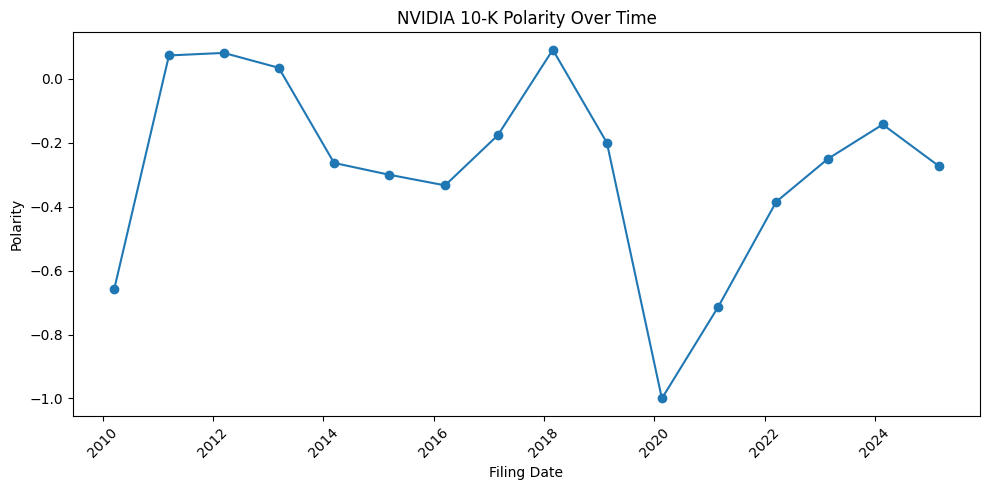

In [208]:
plt.figure(figsize=(10, 5))
plt.plot(plotting["filing_date"], plotting["polarity"], marker="o")
plt.title("NVIDIA 10-K Polarity Over Time")
plt.xlabel("Filing Date")
plt.ylabel("Polarity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

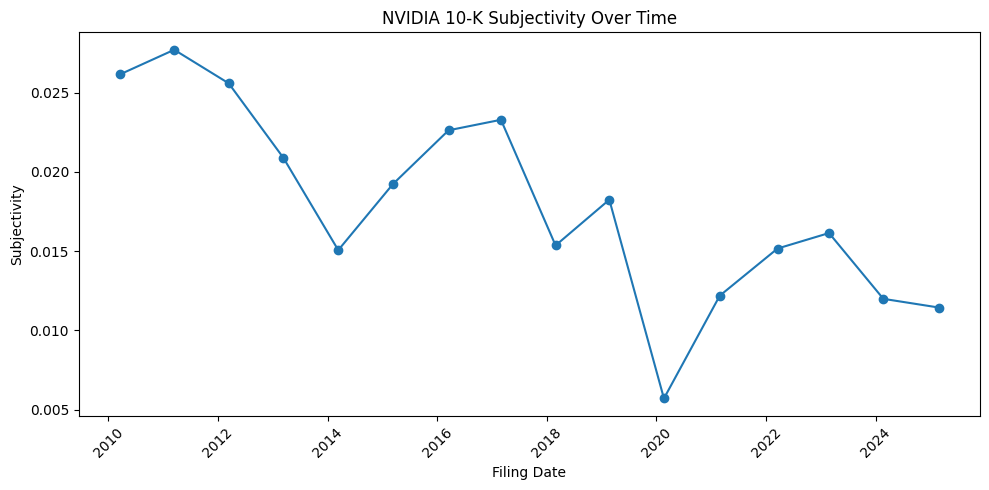

In [209]:
plt.figure(figsize=(10, 5))
plt.plot(plotting["filing_date"], plotting["subjectivity"], marker="o")
plt.title("NVIDIA 10-K Subjectivity Over Time")
plt.xlabel("Filing Date")
plt.ylabel("Subjectivity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

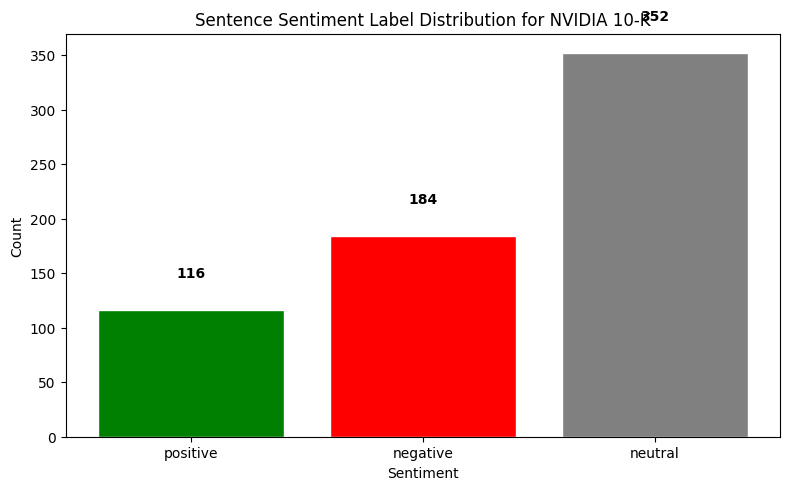

In [210]:
# Show total sentence sentiment distribution

palette = {
    "positive": "green",
    "negative": "red",
    "neutral": "gray"
}

# choose your dataframe here
plot_df = df_pysentiment[
    (df_pysentiment["company_name"].str.contains("nvidia", case=False, na=False)) &
    (df_pysentiment["filing_type"].str.upper() == "10-K")
]

vc_plot = (
    plot_df["sentence_sentiment"] # THIS USES THE PREDICTED SENTENCE SENTIMENT, NOT LABELLED
    .value_counts()
    .reindex(["positive", "negative", "neutral"], fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.bar(
    vc_plot.index,
    vc_plot.values,
    color=[palette[label] for label in vc_plot.index],
    edgecolor="white"
)

plt.title("Sentence Sentiment Label Distribution for NVIDIA 10-K")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, (label, count) in enumerate(vc_plot.items()):
    plt.text(i, count + 30, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# VADER

One issue is that VADER works on the original sentences, not tokenized and preprocessed data. So the results would already be limited

**Because the original natural sentence structure was not fully preserved, VADER results should be interpreted cautiously.**

In [211]:
vader_data_df = data.copy()

vader_data_df.head() # Should be golden copy as we did not touch the original df


,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately NUM of all sales were generated ...,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral


## 1. Just in case, drop any possible empty sentences

In [212]:
vader_data_df = vader_data_df[vader_data_df["sentence"].notna() & (vader_data_df["sentence"].astype(str).str.strip() != "")]

vader_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452390 entries, 0 to 452389
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   doc_id                  452390 non-null  str  
 1   company_name            452390 non-null  str  
 2   filing_type             452390 non-null  str  
 3   filing_date             452390 non-null  str  
 4   year                    452390 non-null  int64
 5   quarter                 452390 non-null  str  
 6   sentence                452390 non-null  str  
 7   golden_sentiment_label  452390 non-null  str  
dtypes: int64(1), str(7)
memory usage: 27.6 MB


## 2. Creation of VADER function, label sentences

In [213]:
vader = SentimentIntensityAnalyzer()

def analyse_VADER(text):
    score = vader.polarity_scores(str(text))
    
    return pd.Series({"vader_neg": score["neg"], "vader_pos": score["pos"], "vader_neu": score["neu"], "vader_compound": score["compound"]})

# COMPOUND SCORE summarises the overall sentiment direction and strength, closer to 1 means strongly positive

In [214]:
vader_scores = vader_data_df["sentence"].apply(analyse_VADER)
vader_df = pd.concat([vader_data_df, vader_scores], axis=1)


In [215]:
# Attempt to label sentiment based on compound score;

def label_vader(compound): # Standard thresholds
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

vader_df["vader_sentiment_label"] = vader_df["vader_compound"].apply(label_vader)

In [216]:
vader_df.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,sentence,golden_sentiment_label,vader_neg,vader_pos,vader_neu,vader_compound,vader_sentiment_label
0,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,presently the companys product line includes a...,neutral,0.000,0.123,0.877,0.4754,positive
1,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,approximately NUM of all sales were generated ...,neutral,0.000,0.000,1.000,0.0000,neutral
2,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,on an ongoing basis we re-evaluate our judgmen...,neutral,0.143,0.000,0.857,-0.5423,negative
3,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,we base our estimates and judgments on our his...,neutral,0.000,0.000,1.000,0.0000,neutral
4,1-800-PetMeds_10-Q_2020-01-28,1-800-PetMeds,10-Q,2020-01-28,2020,Q1,actual results may differ from these estimates...,neutral,0.000,0.000,1.000,0.0000,neutral


## 3. Aggregate into each document for sentiment analysis (again)

In [217]:
vader_doc_summary = (
    vader_df.groupby(
        ["doc_id", "company_name", "filing_type", "filing_date", "year", "quarter"],
        as_index=False
    )
    .agg(
        num_sentences=("sentence", "count"),
        avg_vader_neg=("vader_neg", "mean"),
        avg_vader_neu=("vader_neu", "mean"),
        avg_vader_pos=("vader_pos", "mean"),
        avg_vader_compound=("vader_compound", "mean"),
        median_vader_compound=("vader_compound", "median")
    )
)


# One issue here already is that by using mean, a short sentence and long sentence are equally important.

In [218]:
vader_doc_summary.head()

,doc_id,company_name,filing_type,filing_date,year,quarter,num_sentences,avg_vader_neg,avg_vader_neu,avg_vader_pos,avg_vader_compound,median_vader_compound
0,1-800-PetMeds_10-K_2020-05-26,1-800-PetMeds,10-K,2020-05-26,2020,Q2,19,0.031842,0.846211,0.121895,0.271421,0.2960
1,1-800-PetMeds_10-K_2021-05-25,1-800-PetMeds,10-K,2021-05-25,2021,Q2,11,0.054182,0.839000,0.106818,0.201155,0.0790
2,1-800-PetMeds_10-K_2022-05-24,1-800-PetMeds,10-K,2022-05-24,2022,Q2,9,0.005889,0.927222,0.066889,0.183933,0.2732
3,1-800-PetMeds_10-K_2023-05-23,1-800-PetMeds,10-K,2023-05-23,2023,Q2,55,0.073673,0.850673,0.075618,0.013538,0.0000
4,1-800-PetMeds_10-K_2024-06-14,1-800-PetMeds,10-K,2024-06-14,2024,Q2,8,0.038750,0.936500,0.024750,0.012462,0.0000


In [219]:
doc_text_df = (
    vader_df.groupby("doc_id", as_index=False)
    .agg(document_text=("sentence", " ".join))
)

doc_scores = doc_text_df["document_text"].apply(lambda x: pd.Series(vader.polarity_scores(x)))
doc_text_df = pd.concat([doc_text_df, doc_scores.add_prefix("doc_vader_")], axis=1)

In [220]:
doc_text_df.head()

,doc_id,document_text,doc_vader_neg,doc_vader_neu,doc_vader_pos,doc_vader_compound
0,1-800-PetMeds_10-K_2020-05-26,approximately NUM of all sales were generated ...,0.030,0.857,0.113,0.9907
1,1-800-PetMeds_10-K_2021-05-25,fiscal NUM started out with greater than expec...,0.050,0.831,0.120,0.9590
2,1-800-PetMeds_10-K_2022-05-24,we have continued with working from home where...,0.000,0.942,0.058,0.8990
3,1-800-PetMeds_10-K_2023-05-23,management does not believe that the resolutio...,0.077,0.846,0.077,-0.6385
4,1-800-PetMeds_10-K_2024-06-14,NUM we have direct buying relationships with a...,0.025,0.946,0.028,0.1280


### 4. Visualise VADER

In [221]:
# 10-K for nvidia

vader_doc_summary["filing_date"] = pd.to_datetime(vader_doc_summary["filing_date"])

nvidia_10k = (
    vader_doc_summary[
        (vader_doc_summary["company_name"].str.contains("nvidia", case=False, na=False)) &
        (vader_doc_summary["filing_type"].str.upper() == "10-K")
    ]
    .sort_values("filing_date")
)

nvidia_10k[["filing_date", "avg_vader_compound", "median_vader_compound"]]
# Higher means that document is more positive in tone

,filing_date,avg_vader_compound,median_vader_compound
9827,2010-03-18,0.236955,0.29600
9828,2011-03-16,0.394667,0.40190
9829,2012-03-13,0.331837,0.42150
9830,2013-03-12,0.260818,0.20230
9831,2014-03-13,0.217845,0.17790
9832,2015-03-12,0.331584,0.36120
9833,2016-03-17,0.210935,0.17790
9834,2017-03-01,0.380338,0.47410
9835,2018-02-28,0.385329,0.54205
9836,2019-02-21,0.177838,0.23150


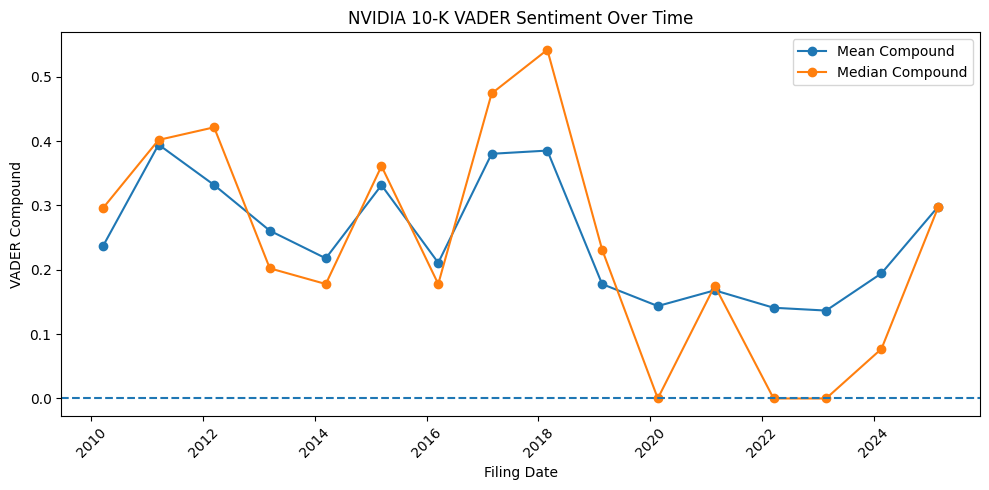

In [222]:
plt.figure(figsize=(10, 5))
plt.plot(nvidia_10k["filing_date"], nvidia_10k["avg_vader_compound"], marker="o", label="Mean Compound")
plt.plot(nvidia_10k["filing_date"], nvidia_10k["median_vader_compound"], marker="o", label="Median Compound")
plt.axhline(0, linestyle="--")
plt.title("NVIDIA 10-K VADER Sentiment Over Time")
plt.xlabel("Filing Date")
plt.ylabel("VADER Compound")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation of LM and VADER Rule-based sentiment analysis
We evaluate based on the golden_sentiment_label provided and determine accuracy, precision and recall

## LM Analysis

In [223]:
pd.crosstab(df_pysentiment["golden_sentiment_label"], df_pysentiment["sentence_sentiment"], margins=True)

sentence_sentiment,negative,neutral,positive,All
golden_sentiment_label,,,,
negative,15646,16177,4617,36440
neutral,103385,200568,74433,378386
positive,4250,21397,11917,37564
All,123281,238142,90967,452390


Analysis (LM - Pysentiment2): 

Out of all true negative sentences, `15646/36440` were classified correctly = **42.9%** Recall

Out of all true neutral sentences, `200568/378386` were classified correctly = **53.0%** Recall

Out of all true positive sentences, `11917/37564` were classified correctly = **31.7%** Recall


**Overall Accuracy**: `(15646+200568+11917)/452390 * 100%` = **50.4%**

**Negative Precision**: `15646 / 123281 * 100%` = **12.7%** __When model predicts Negative, how often is it right?__

**Neutral Precision**: `200568 / 238142 * 100%` = **84.2%**

**Positive Precision**: `11917 / 90967 * 100%` = **13.1%**



In [224]:
pd.crosstab(df_custom["golden_sentiment_label"], df_custom["sentence_sentiment"], margins=True)

sentence_sentiment,negative,neutral,positive,All
golden_sentiment_label,,,,
negative,15447,18671,2322,36440
neutral,80033,255569,42784,378386
positive,2853,23411,11300,37564
All,98333,297651,56406,452390


Analysis (LM): 

Out of all true negative sentences, `15447/36440` were classified correctly = **42.4%** Recall

Out of all true neutral sentences, `255569/378386` were classified correctly = **67.5%** Recall

Out of all true positive sentences, `11300/37564` were classified correctly = **30.1%** Recall

**Overall Accuracy**: `(15447 + 255569 + 11300)/452390 * 100%` = **62.4%**

**Negative Precision**: `15447 / 98333 * 100%` = **15.7%** __When model predicts Negative, how often is it right?__

**Neutral Precision**: `255569 / 297651 * 100%` = **85.9%**

**Positive Precision**: `11300 / 56406 * 100%` = **20.0%**

## VADER Analysis

In [225]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("Accuracy:", accuracy_score(vader_df["golden_sentiment_label"], vader_df["vader_sentiment_label"]))
print()
print(classification_report(vader_df["golden_sentiment_label"], vader_df["vader_sentiment_label"]))

cm = confusion_matrix(
    vader_df["golden_sentiment_label"],
    vader_df["vader_sentiment_label"],
    labels=["negative", "neutral", "positive"]
)

cm_df = pd.DataFrame(
    cm,
    index=["negative", "neutral", "positive"],
    columns=["negative", "neutral", "positive"]
)

cm_df

Accuracy: 0.3153120095492827

              precision    recall  f1-score   support

    negative       0.17      0.34      0.23     36440
     neutral       0.92      0.26      0.40    378386
    positive       0.12      0.86      0.21     37564

    accuracy                           0.32    452390
   macro avg       0.40      0.49      0.28    452390
weighted avg       0.79      0.32      0.37    452390



,negative,neutral,positive
negative,12548,6176,17716
neutral,59375,97849,221162
positive,2717,2600,32247


## Overall Comparison

A challenge that was faced overall is the class imbalance in the dataset, as it contains mainly neutral sentences.

Evaluation was conducted at the sentence level by comparing against the golden labels. Document-level results (aggregation) are presented as EDA.

<u>**Loughran-McDonald**</u>

Based on the above results, we are able to determine that the custom LM performed better than `pysentiment2`'s LM classifier, having stronger overall accuracy and better precision overall. This means that the predictions were often more correct.

A possible reason for this result is that the custom approach gave more control over the preprocessing and tokenization step. Another possible reason could be that the more updated master dictionary have better financial sentiment terms. Combining both of these, these factors would have helped to reduce noise and made the custom labeller more relibable.

However, a downside of LM is precisely because it uses a dictionary to attempt to determine sentiment. We would count the number of words that have positive/negative sentiments, but do not consider sentence structure, context or intent. Due to this, what would be considered neutral sentences could be misclassified if they contain some words that are deemed to have sentiments.


<u>**VADER**</u>

Based on the above results, VADER did not perform as well as Loughran-McDonald, with an overall accuracy of **31.5%**.

A possible explanation for this result is that VADER is a specialised lexicon which is primarily used with social media text. Due to our preprocessing step, VADER's ability would have been weakened as well, as it relies on capitalisation and punctuation for emphasis. Unsurprisingly, VADER underperformed when compared to LM.


<u>**Conclusion**</u>

The custom LM performed the best on the dataset among the 3 methods that were tested. However, accuracy metric should still be interpreted cautiously due to the issue of class imbalance.